## Exploratory Data Analysis - UCI Heart Disease Dataset

### 1. Objective
### 2. Load Dataset
### 3. Dataset Overview
### 4. Data Types
### 5. Missing Values
### 6. Duplicate Records
### 7. Summary Statistics
### 8. Target Class Distribution
### 9. Numerical Feature Distributions
### 10. Categorical Feature Distributions
### 11. Feature Relationships with Target
### 12. Correlation Analysis
### 13. EDA Findings and Preprocessing Decisions

In [73]:
# Imports
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [74]:
# Dataset loading
PROJECT_ROOT = Path.cwd().parent

DATA_PATH = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "heart_disease.csv"
)

df = pd.read_csv(DATA_PATH)

df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,1,145,233,1,2,150,0,2.3,3,0.0,6.0,0
1,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0,1
2,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0,1
3,37,1,3,130,250,0,0,187,0,3.5,3,0.0,3.0,0
4,41,0,2,130,204,0,2,172,0,1.4,1,0.0,3.0,0


In [75]:
#Dataset overview
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")
print(f"="*80)

df.info()
print(f"="*80)

df.head(10)

Rows: 303
Columns: 14
<class 'pandas.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        299 non-null    float64
 12  thal      301 non-null    float64
 13  target    303 non-null    int64  
dtypes: float64(3), int64(11)
memory usage: 33.3 KB


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,1,145,233,1,2,150,0,2.3,3,0.0,6.0,0
1,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0,1
2,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0,1
3,37,1,3,130,250,0,0,187,0,3.5,3,0.0,3.0,0
4,41,0,2,130,204,0,2,172,0,1.4,1,0.0,3.0,0
5,56,1,2,120,236,0,0,178,0,0.8,1,0.0,3.0,0
6,62,0,4,140,268,0,2,160,0,3.6,3,2.0,3.0,1
7,57,0,4,120,354,0,0,163,1,0.6,1,0.0,3.0,0
8,63,1,4,130,254,0,2,147,0,1.4,2,1.0,7.0,1
9,53,1,4,140,203,1,2,155,1,3.1,3,0.0,7.0,1


The dataset contains 303 patient records, 13 predictive features, and one
binary target variable indicating the presence or absence of heart disease.

In [76]:
# Data types
df.dtypes

age           int64
sex           int64
cp            int64
trestbps      int64
chol          int64
fbs           int64
restecg       int64
thalach       int64
exang         int64
oldpeak     float64
slope         int64
ca          float64
thal        float64
target        int64
dtype: object

In [77]:
numerical_features = [
    "age",
    "trestbps",
    "chol",
    "thalach",
    "oldpeak",
]

categorical_features = [
    "sex",
    "cp",
    "fbs",
    "restecg",
    "exang",
    "slope",
    "ca",
    "thal",
]

Although several variables are stored numerically, some represent categorical
clinical states rather than continuous quantities. These features will be
treated as categorical during preprocessing and model development.

In [78]:
# Step 5 — Missing values
missing_values = df.isnull().sum().sort_values(ascending=False)

missing_percentage = (
    df.isnull().sum() / len(df) * 100
).sort_values(ascending=False)

missing_summary = pd.DataFrame(
    {
        "Missing Count": missing_values,
        "Missing Percentage": missing_percentage,
    }
)

missing_summary

,Missing Count,Missing Percentage
ca,4,1.320132
thal,2,0.660066
cp,0,0.000000
trestbps,0,0.000000
age,0,0.000000
sex,0,0.000000
fbs,0,0.000000
chol,0,0.000000
restecg,0,0.000000
thalach,0,0.000000


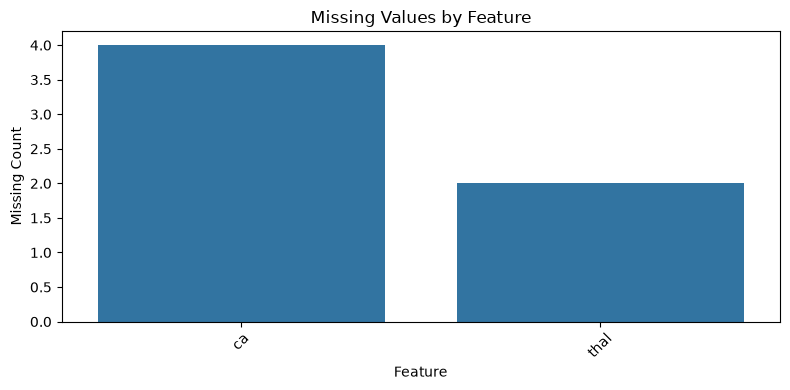

In [79]:
missing_plot = missing_summary[
    missing_summary["Missing Count"] > 0
]

plt.figure(figsize=(8, 4))

sns.barplot(
    x=missing_plot.index,
    y=missing_plot["Missing Count"],
)

plt.title("Missing Values by Feature")
plt.xlabel("Feature")
plt.ylabel("Missing Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [80]:
# Step 6 — Duplicate records
duplicate_count = df.duplicated().sum()

print(f"Duplicate rows: {duplicate_count}")

Duplicate rows: 0


In [81]:
# Step 7 — Summary statistics
df.describe().T

df[numerical_features].describe().T

,count,mean,std,min,25%,50%,75%,max
age,303.0,54.438944,9.038662,29.0,48.0,56.0,61.0,77.0
trestbps,303.0,131.689769,17.599748,94.0,120.0,130.0,140.0,200.0
chol,303.0,246.693069,51.776918,126.0,211.0,241.0,275.0,564.0
thalach,303.0,149.607261,22.875003,71.0,133.5,153.0,166.0,202.0
oldpeak,303.0,1.039604,1.161075,0.0,0.0,0.8,1.6,6.2


In [82]:
# Step 8 — Target class balance
df["target"].value_counts()

df["target"].value_counts(normalize=True) * 100

target
0    54.125413
1    45.874587
Name: proportion, dtype: float64

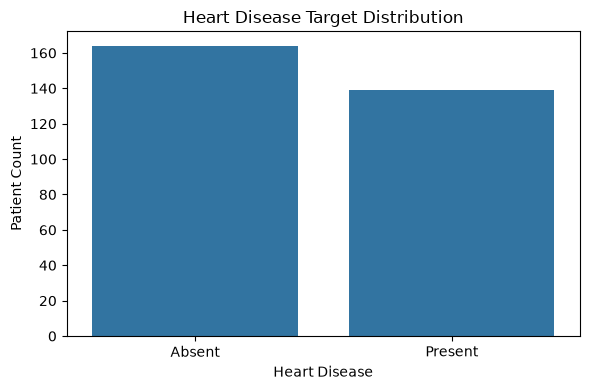

In [83]:
plt.figure(figsize=(6, 4))

sns.countplot(
    data=df,
    x="target",
)

plt.title("Heart Disease Target Distribution")
plt.xlabel("Heart Disease")
plt.ylabel("Patient Count")

plt.xticks(
    ticks=[0, 1],
    labels=["Absent", "Present"],
)

plt.tight_layout()
plt.show()

The target variable is relatively balanced, with approximately 54% of records
representing absence of heart disease and 46% representing presence of heart
disease. Therefore, severe class imbalance mitigation techniques are not
required initially.

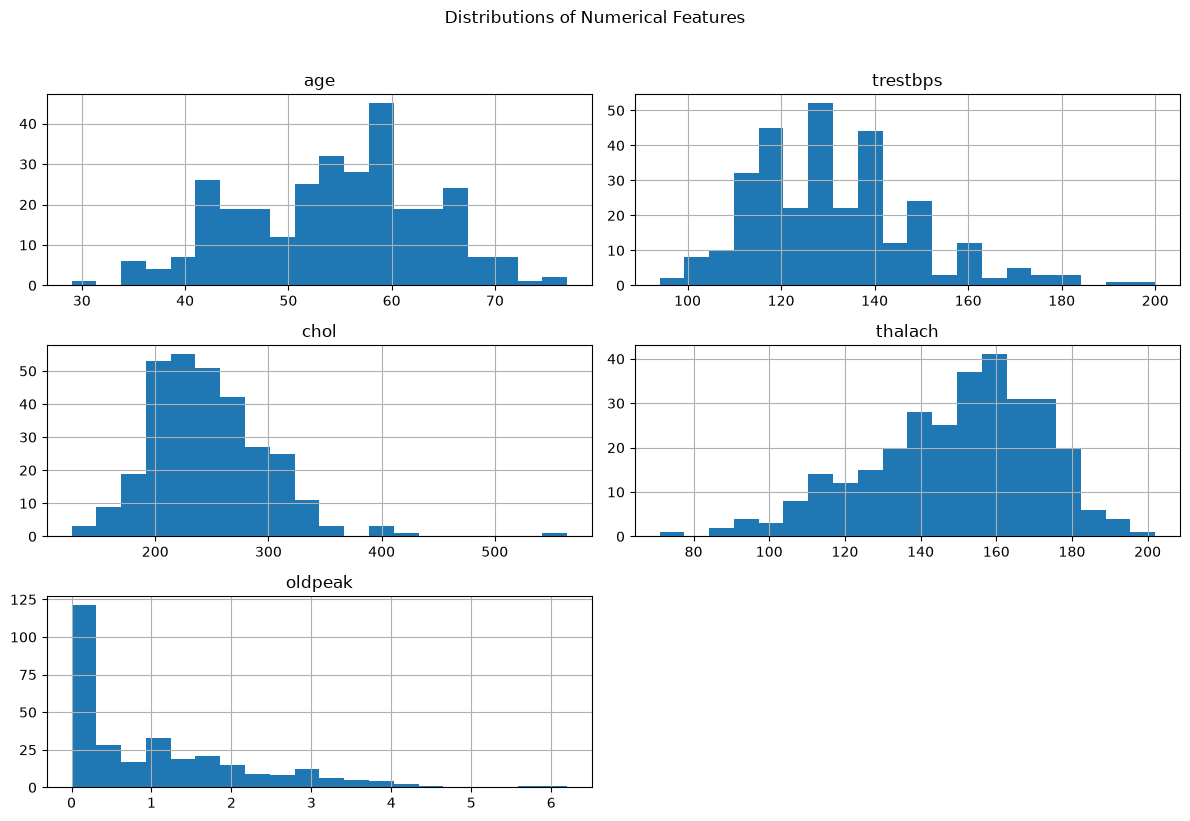

In [84]:
# Step 9 — Numerical distributions

#Histogram
df[numerical_features].hist(
    figsize=(12, 8),
    bins=20,
)

plt.suptitle(
    "Distributions of Numerical Features",
    y=1.02,
)

plt.tight_layout()
plt.show()

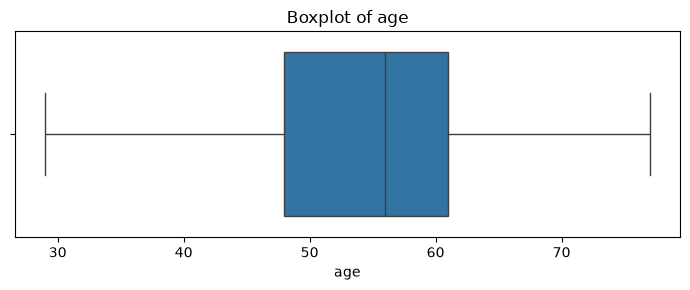

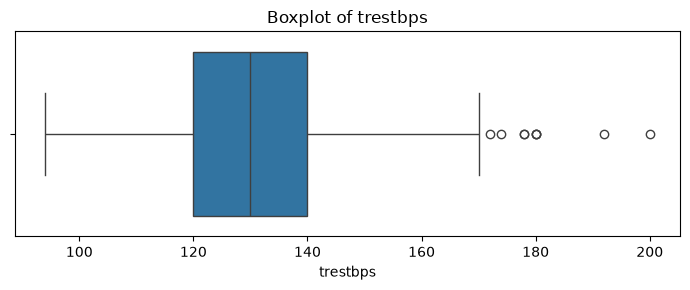

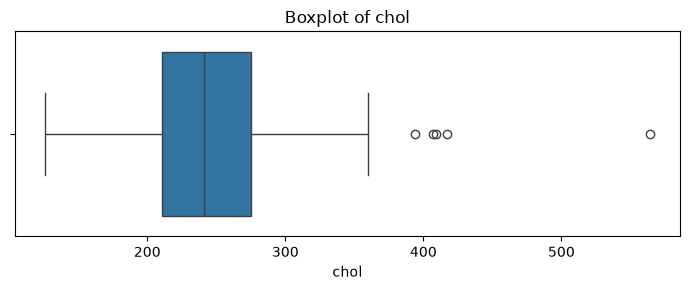

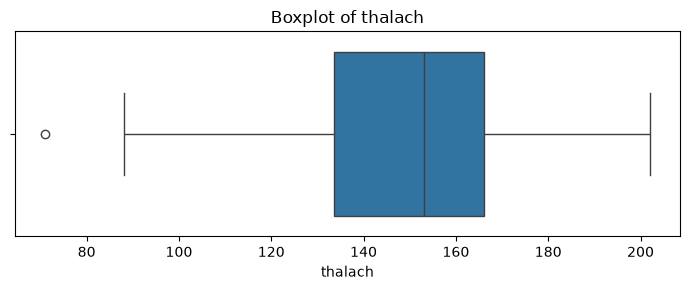

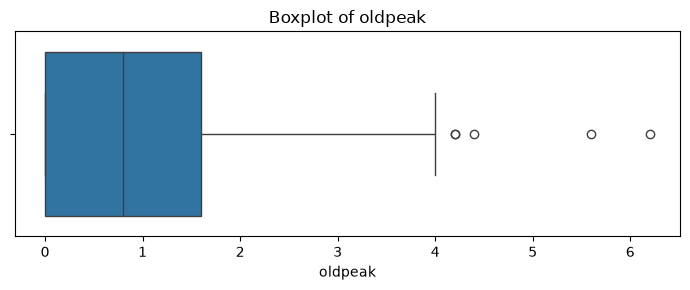

In [85]:
# Boxplot
for column in numerical_features:
    plt.figure(figsize=(7, 3))

    sns.boxplot(
        x=df[column],
    )

    plt.title(f"Boxplot of {column}")
    plt.tight_layout()
    plt.show()

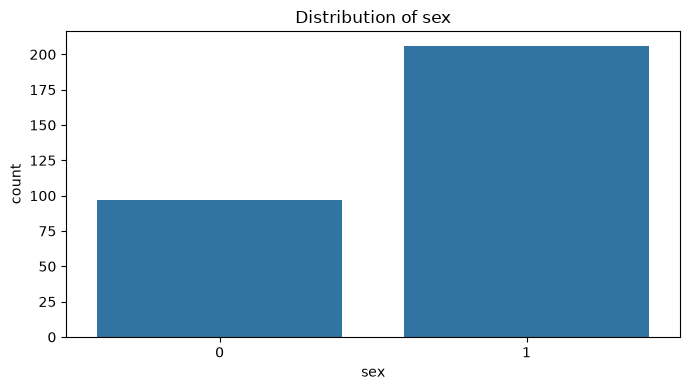

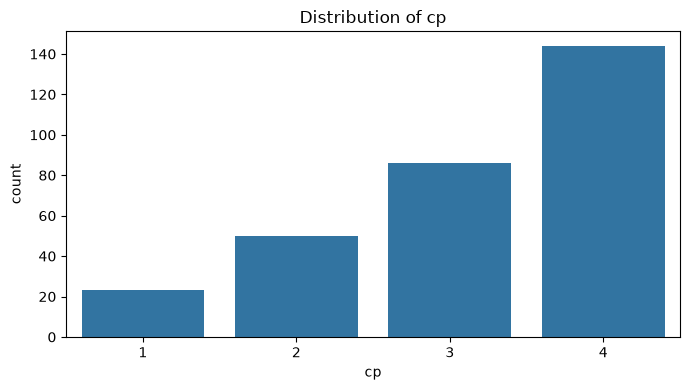

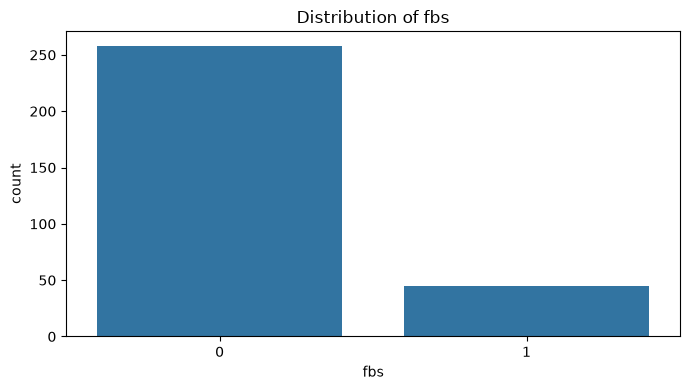

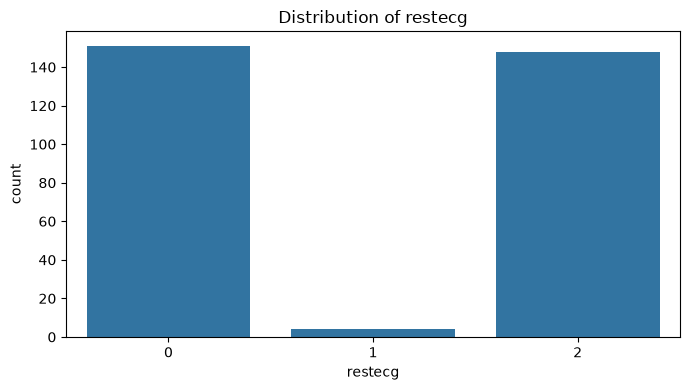

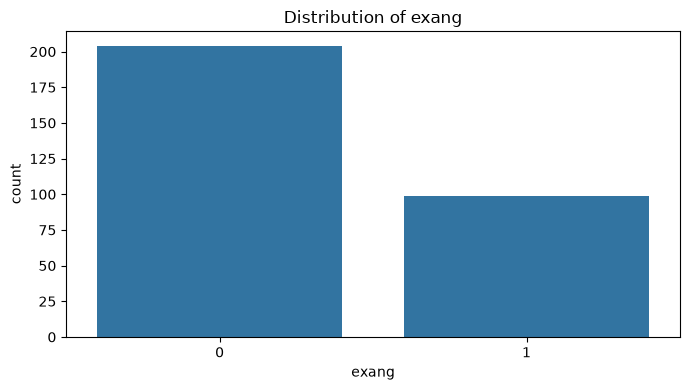

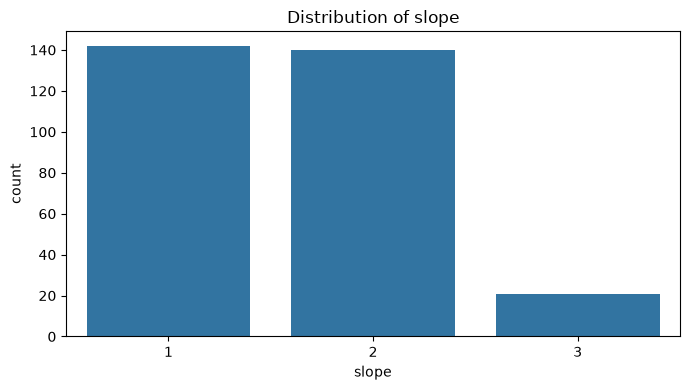

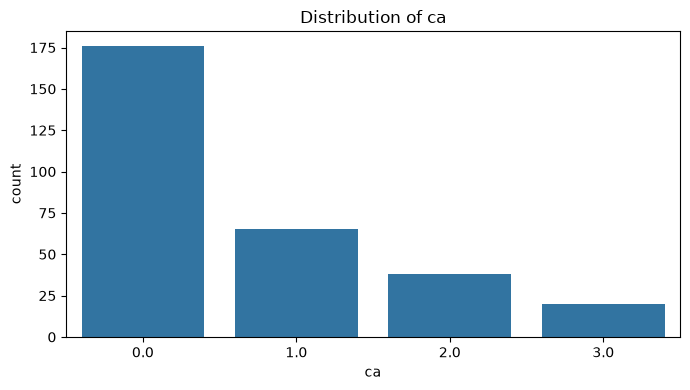

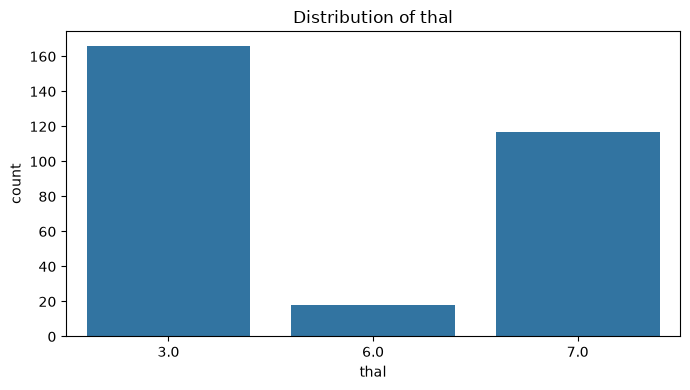

In [86]:
# Step 10 — Categorical feature distributions
for column in categorical_features:
    plt.figure(figsize=(7, 4))

    sns.countplot(
        data=df,
        x=column,
    )

    plt.title(f"Distribution of {column}")
    plt.tight_layout()
    plt.show()

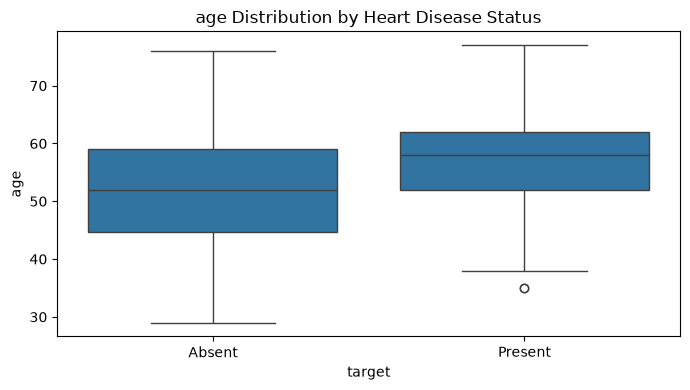

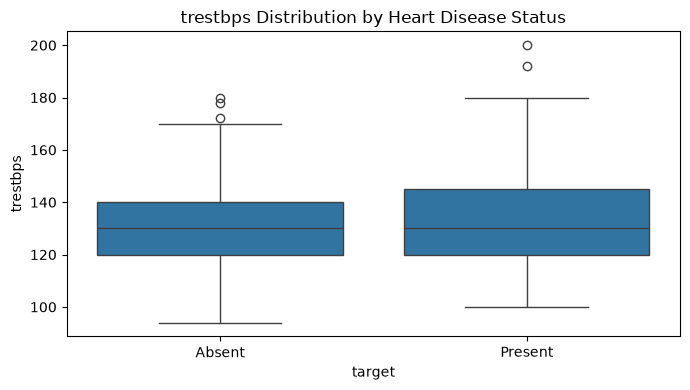

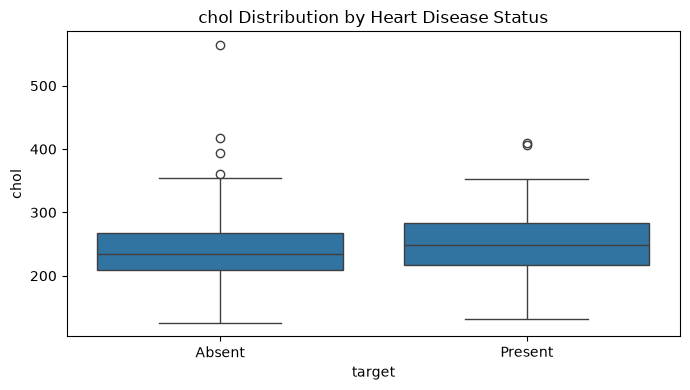

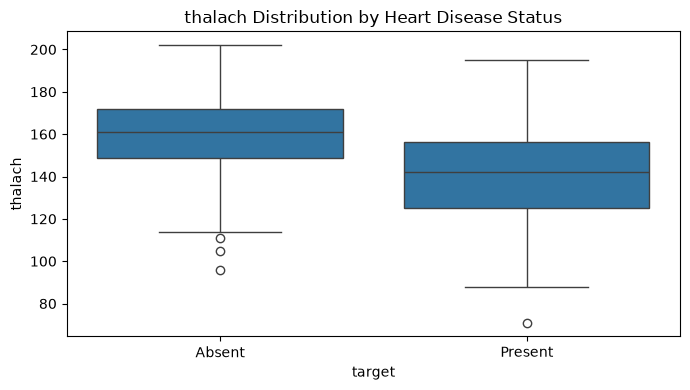

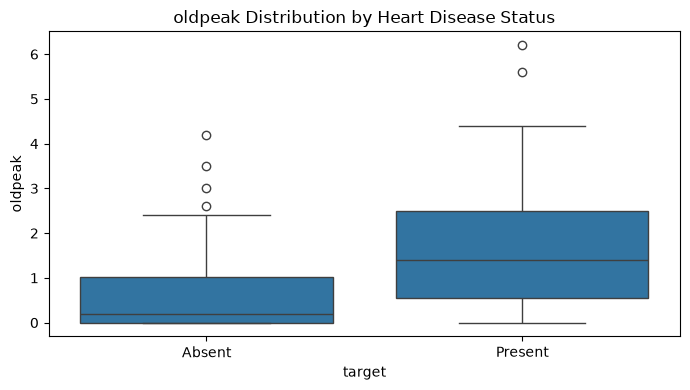

In [87]:
# Step 11 — Numerical features vs target
for column in numerical_features:
    plt.figure(figsize=(7, 4))

    sns.boxplot(
        data=df,
        x="target",
        y=column,
    )

    plt.title(
        f"{column} Distribution by Heart Disease Status"
    )

    plt.xticks(
        ticks=[0, 1],
        labels=["Absent", "Present"],
    )

    plt.tight_layout()
    plt.show()

In [88]:
# Step 12 — Categorical features vs target

pd.crosstab(
    df["cp"],
    df["target"],
    normalize="index",
)

target,0,1
cp,,
1,0.695652,0.304348
2,0.820000,0.180000
3,0.790698,0.209302
4,0.270833,0.729167


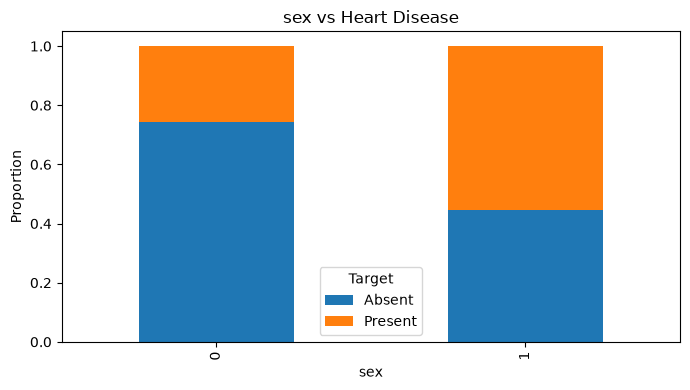

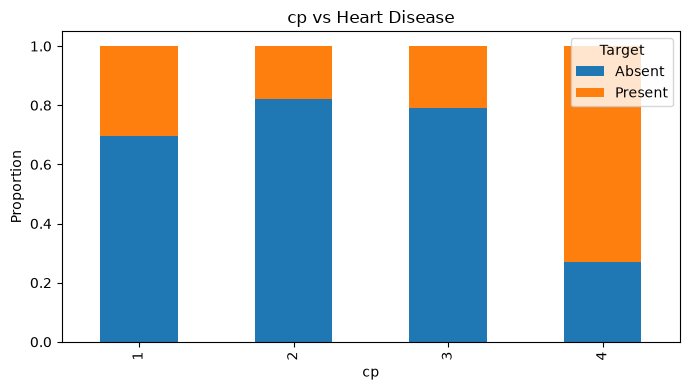

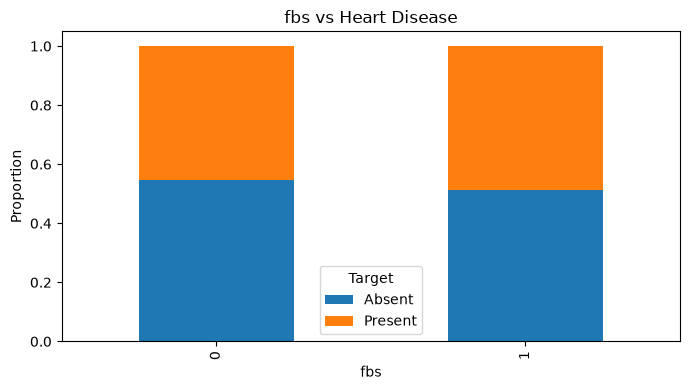

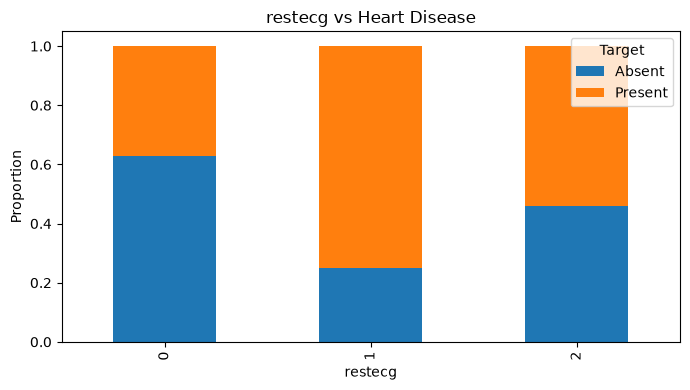

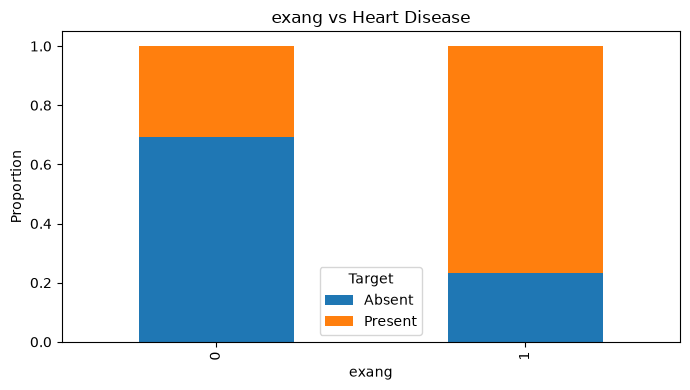

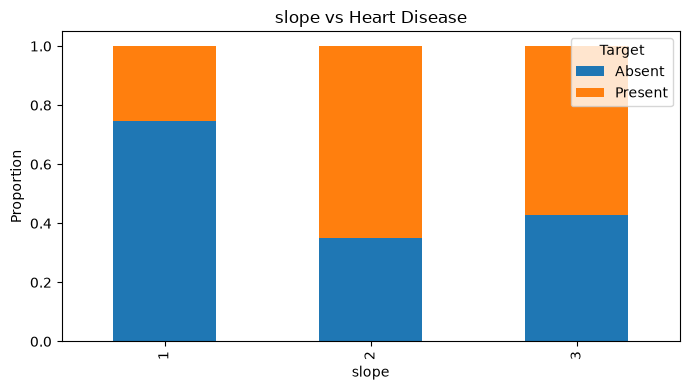

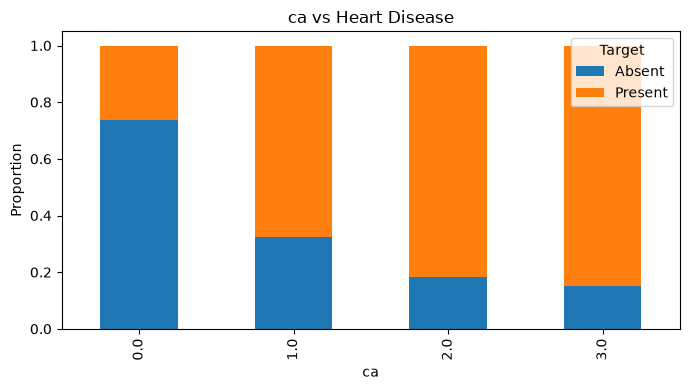

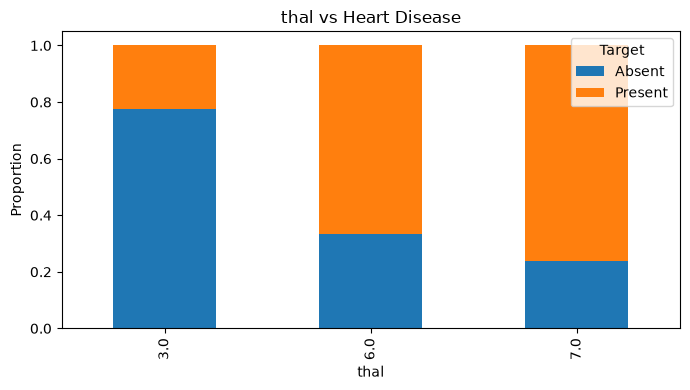

In [89]:
for column in categorical_features:
    ct = pd.crosstab(
        df[column],
        df["target"],
        normalize="index",
    )

    ct.plot(
        kind="bar",
        stacked=True,
        figsize=(7, 4),
    )

    plt.title(
        f"{column} vs Heart Disease"
    )

    plt.ylabel("Proportion")
    plt.legend(
        ["Absent", "Present"],
        title="Target",
    )

    plt.tight_layout()
    plt.show()

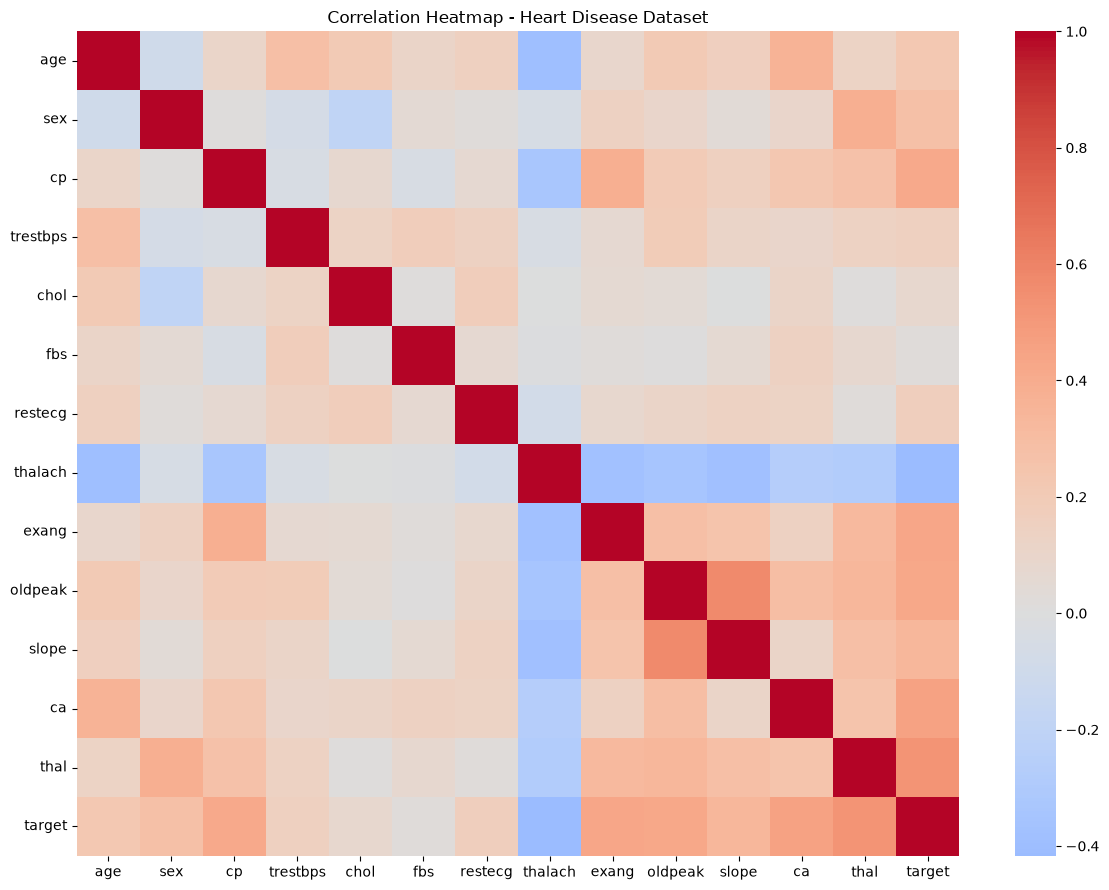

In [90]:
# Step 13 — Correlation analysis
correlation_matrix = df.corr(numeric_only=True)

plt.figure(figsize=(12, 9))

sns.heatmap(
    correlation_matrix,
    cmap="coolwarm",
    center=0,
)

plt.title(
    "Correlation Heatmap - Heart Disease Dataset"
)

plt.tight_layout()
plt.show()

In [91]:
target_correlations = (
    correlation_matrix["target"]
    .drop("target")
    .sort_values(
        key=abs,
        ascending=False,
    )
)

target_correlations

thal        0.525689
ca          0.460442
exang       0.431894
oldpeak     0.424510
thalach    -0.417167
cp          0.414446
slope       0.339213
sex         0.276816
age         0.223120
restecg     0.169202
trestbps    0.150825
chol        0.085164
fbs         0.025264
Name: target, dtype: float64

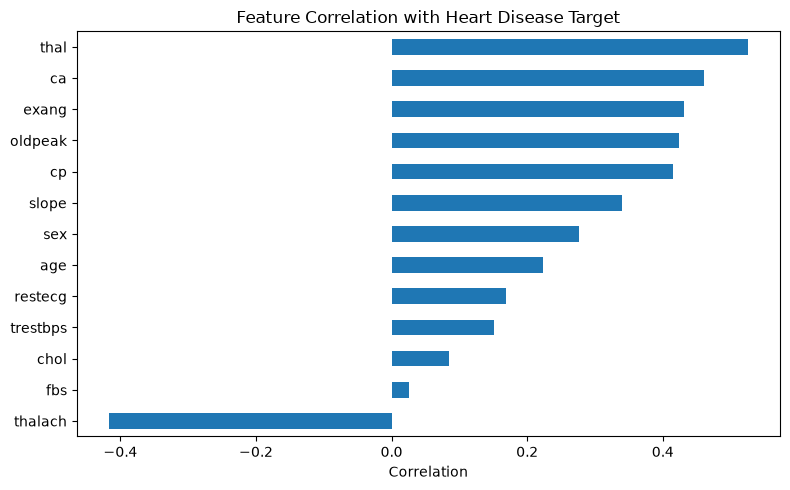

In [92]:
# Step 14 — Add a useful target-correlation plot
plt.figure(figsize=(8, 5))

target_correlations.sort_values().plot(
    kind="barh"
)

plt.title(
    "Feature Correlation with Heart Disease Target"
)
plt.xlabel("Correlation")
plt.tight_layout()
plt.show()

In [93]:
# Step 15 — EDA findings section
# Dataset size
# Missing values
# Duplicate count
# Target balance
# Important feature relationships
# Potential outliers
# Numerical vs categorical features
# Preprocessing requirements

- The dataset contains 303 observations and 13 predictive variables.
- The target is relatively balanced.
- Missing values are present in selected features.
- Some integer-coded variables are categorical rather than continuous.
- Numerical variables have different scales.
- Certain features show visible relationships with the target.
- Preprocessing should therefore include imputation, categorical encoding,
  and scaling for numerical features.